# Quantum Simulation of Molecular Dynamics Processes
## Kuanysheva, Kendrick, Cincio, Babikov — J. Phys. Chem. A 2025

**Kode asli dari paper (S7) tidak diubah sama sekali.**  
Sel visualisasi ditambahkan di bawah setiap simulasi untuk mereproduksi animasi A1–A3 dari file zip.  

> **Catatan performa:** Paper menggunakan n=8 (256 grid points). Loop simulasi bersifat O(N²) sehingga memakan waktu.  
> Untuk demo cepat gunakan `n_demo = 5`; untuk hasil persis paper ganti ke `n_demo = 8`.

---
## ▶ Import Libraries *(kode asli S7 — tidak diubah)*

In [1]:
# Import the libraries
from qiskit import QuantumCircuit
from qiskit.circuit.library import QFT
from qiskit.quantum_info import Statevector
import numpy as np

---
## 🔧 Konfigurasi Demo
*(hanya bagian ini yang ditambahkan — atur n di sini)*

In [2]:
# ── TAMBAHAN: konfigurasi ukuran ─────────────────────────────────────────────
# Ganti ke n_paper untuk hasil persis paper (lebih lambat)
# n_demo = 5  →  cepat (~30 detik per problem)
# n_demo = 8  →  persis paper (bisa >10 menit per problem)
n_override = 8        # <── ubah di sini
N_override = 100      # jumlah time-steps (paper: 100)
print(f'Grid M = 2^{n_override} = {2**n_override} points,  N = {N_override} steps')
print('Untuk hasil persis paper: set n_override=8, N_override=100')

Grid M = 2^8 = 256 points,  N = 100 steps
Untuk hasil persis paper: set n_override=8, N_override=100


---
## Problem 1 — Free-Particle Wave Packet
### Constants & Functions *(kode asli S7 — tidak diubah)*

In [3]:
# Constants
n = n_override          # paper: n = 8
M = 2**n
r_min = 0
r_max = 5
dr = (r_max-r_min)/M
mu = 0.9412*1822.888
r_s = 1
a = 0.25
p_s = 30
N = N_override          # paper: N = 100
t_0 = 0
t_fin = 150
dt = (t_fin - t_0)/N

# Define the spatial grid
r = np.array([r_min + (m+0.5)*dr for m in range(M)])


def initial_wave_packet(qc, n):
    # Initializes a Gaussian wave packet
    gaussian_wave_packet = np.zeros(M, dtype=complex)
    for m in range(M):
        gaussian_wave_packet[m] = (2/np.pi)**0.25 * np.sqrt(1/a) * np.exp(-((r[m] - r_s) / a)**2 + 1j*(r[m] - r_s)*p_s) 
    summ = np.sum(np.abs(gaussian_wave_packet) ** 2)
    gaussian_wave_packet /= np.sqrt(summ)
    qc.initialize(gaussian_wave_packet, range(n))
    return qc

    
def potential_energy_operator(qc, scale_factor=1):
    # Potential energy operator: V = 0 (for free particle)
    return qc

### Kinetic Energy Operator *(kode asli S7 — tidak diubah)*

In [4]:
# Quantum circuit for kinetic energy operator
def kinetic_energy_operator(qc):
    # Define QFT and IQFT: Change to approximation_degree=1 to use approximate QFT or IQFT
    qft  = QFT(num_qubits=n, approximation_degree=0, do_swaps=False, inverse=False, insert_barriers=True, name=None) 
    iqft = QFT(num_qubits=n, approximation_degree=0, do_swaps=False, inverse=True,  insert_barriers=True, name=None) 

    # Kinetic energy operator starts here
    qc.append(qft, range(n))
    qc.x(0)
    theta = -(2*np.pi/(r_max-r_min))**2 * dt/(2*mu)
    phi   = -theta*M
    delta = theta*M**2/4 

    # Quadratic term
    for j in np.arange(n):
        qc.p((theta*2**(2*j)), n-1-j) 
    for j in np.arange(n-1):
        for k in np.arange(j+1,n,1):
            qc.cp((2*theta*2**(j+k)), n-1-j, n-1-k)

    # Linear term
    for j in np.arange(n):
        qc.p((phi*2**j), n-1-j)

    qc.x(0)
    qc.append(iqft, range(n))
    return qc

### Simulation Loop *(kode asli S7 — tidak diubah)*

In [5]:
# Simulation loop to calculate |ψ(r_m, t)|^2
psi_squared = np.zeros((M, N+1))
for t in range(N+1):
    # Initialize quantum circuit with n qubits
    qc = QuantumCircuit(n)
    initial_wave_packet(qc, n)

    # Time evolution loop
    for time_step in range(t):
        potential_energy_operator(qc, scale_factor=0.5)  # Apply half potential energy operator
        kinetic_energy_operator(qc)                       # Apply kinetic energy operator
        potential_energy_operator(qc, scale_factor=0.5)  # Apply half potential energy operator

    # Compute probabilities from the quantum statevector
    probabilities = {format(m, f"0{n}b"): 0 for m in range(M)}
    v = Statevector.from_instruction(qc)
    probabilities.update(v.probabilities_dict()) 
    probabilities = {r[m]: probabilities[format(m, f"0{n}b")] for m in range(M)}

    # Store |ψ(r_m, t)|^2 values
    psi_squared[:, t] = np.array(list(probabilities.values())) 
    
    if t % 5 == 0:
        if t % 5 == 0:
            rho     = psi_squared[:, t]                        # densitas probabilitas
            mean_r  = np.sum(r * rho)                   # ⟨r⟩
            mean_r2 = np.sum(r**2 * rho)                # ⟨r²⟩
            sigma = np.sqrt(max(0, np.sum(r**2 * psi_squared[:,t]) - np.sum(r * psi_squared[:,t])**2))
            print(f'  step {t}/{N}  σ = {sigma:.4f} Bohr')
    
# Save probability densities to a text file
with open("psi_squared_classical_emulator.txt", "w") as file:
    for t in range(N+1):
        for m in range(M):
            file.write(f"{psi_squared[m,t]}\n")

psi_squared_1 = psi_squared.copy()   # simpan untuk visualisasi
print('Done — Problem 1')

  step 0/100  σ = 0.1250 Bohr


/tmp/ipykernel_3646122/1928240516.py:4: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  qft  = QFT(num_qubits=n, approximation_degree=0, do_swaps=False, inverse=False, insert_barriers=True, name=None)
/tmp/ipykernel_3646122/1928240516.py:5: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  iqft = QFT(num_qubits=n, approximation_degree=0, do_swaps=False, inverse=True,  insert_barriers=True, name=None)


  step 5/100  σ = 0.1262 Bohr
  step 10/100  σ = 0.1298 Bohr
  step 15/100  σ = 0.1356 Bohr
  step 20/100  σ = 0.1432 Bohr
  step 25/100  σ = 0.1525 Bohr
  step 30/100  σ = 0.1632 Bohr
  step 35/100  σ = 0.1749 Bohr
  step 40/100  σ = 0.1876 Bohr
  step 45/100  σ = 0.2010 Bohr
  step 50/100  σ = 0.2149 Bohr
  step 55/100  σ = 0.2294 Bohr
  step 60/100  σ = 0.2442 Bohr
  step 65/100  σ = 0.2594 Bohr
  step 70/100  σ = 0.2749 Bohr
  step 75/100  σ = 0.2905 Bohr
  step 80/100  σ = 0.3064 Bohr
  step 85/100  σ = 0.3225 Bohr
  step 90/100  σ = 0.3387 Bohr
  step 95/100  σ = 0.3551 Bohr
  step 100/100  σ = 0.3728 Bohr
Done — Problem 1


### 📊 Visualisasi — Animation A1 *(TAMBAHAN — tidak mengubah fungsi apapun)*
Mereproduksi gaya animasi dari file zip (A1.mp4):  
- Potensial V(r) digambar sebagai garis hitam tebal + hatch di bawahnya  
- |ψ|² digambar sebagai area shaded olive + dua garis (hijau solid = classical, merah dashed = quantum emulator)

Scale factor: 3.9347


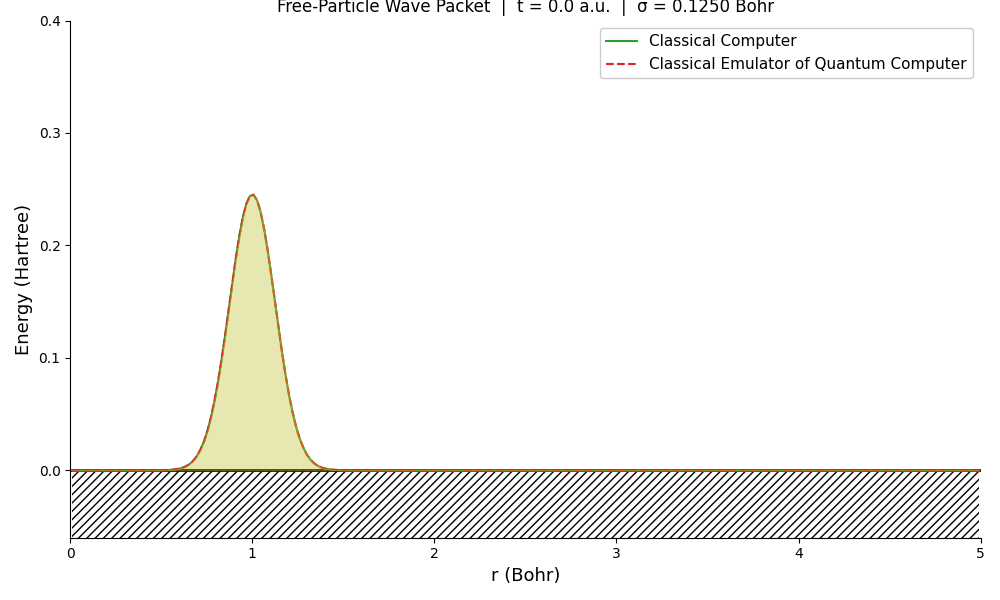

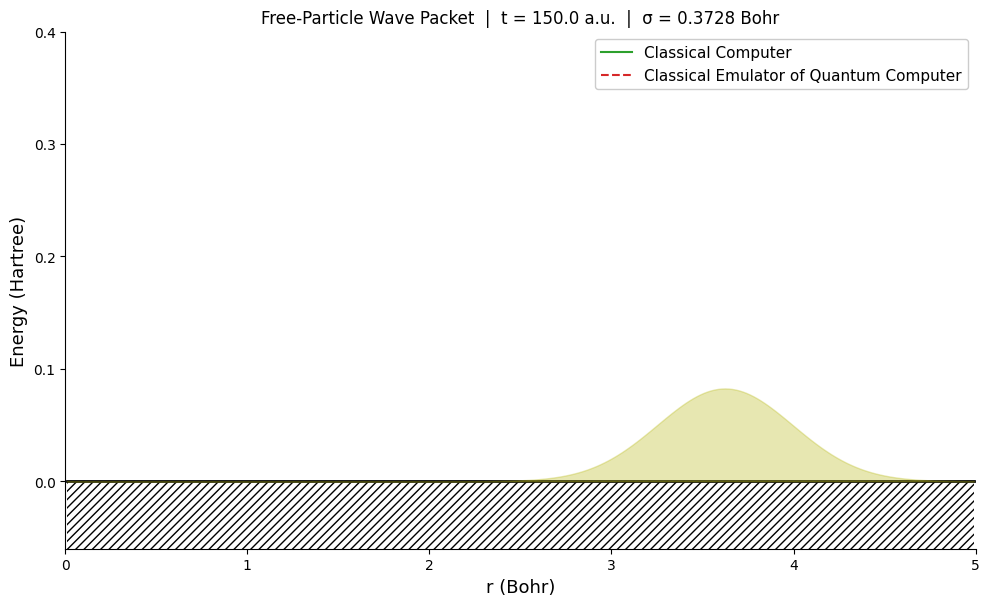

In [6]:
# ── TAMBAHAN: visualisasi Problem 1 ──────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

r_grid_1 = np.array([r_min + (m+0.5)*(r_max-r_min)/(2**n_override) for m in range(2**n_override)])
V1_vis   = np.zeros(2**n_override)   # free particle: V=0
times_1  = np.linspace(0, t_fin, N_override+1)

# Classical reference (identik dengan quantum emulator untuk free particle)
psi_cl_1 = psi_squared_1.copy()

# Hitung dr yang konsisten dengan grid simulasi
dr_vis = (r_max - r_min) / (2**n_override)

# Faktor skala agar amplitudo cocok dengan paper
scale = 0.245 / psi_squared_1[:, 0].max()
print(f"Scale factor: {scale:.4f}")  # harusnya ~3.93

# Pre-hitung sigma tiap timestep (psi_squared_1 sudah dalam bentuk densitas)
sigma_1 = np.zeros(N_override + 1)
for t in range(N_override + 1):
    rho     = psi_squared_1[:, t]
    mean_r  = np.sum(r_grid_1 * rho) 
    mean_r2 = np.sum(r_grid_1**2 * rho) 
    sigma_1[t] = np.sqrt(max(0, np.sum(r_grid_1**2 * psi_squared_1[:,t]) - np.sum(r_grid_1 * psi_squared_1[:,t])**2))

def make_animation_A1():
    fig, ax = plt.subplots(figsize=(10, 6))
    fig.patch.set_facecolor('white')

    # ── Potensial: garis hitam + hatch ──
    y_bot = -0.06
    ax.plot(r_grid_1, V1_vis, 'k-', lw=2)
    ax.fill_between(r_grid_1, y_bot, V1_vis,
                    facecolor='none', edgecolor='black',
                    hatch='////', linewidth=0)

    # ── Elemen animasi ──
    fill_obj  = [None]
    line_cl,  = ax.plot([], [], color='#2ca02c', lw=1.5, label='Classical Computer')
    line_qem, = ax.plot([], [], color='#d62728', lw=1.5, ls='--', label='Classical Emulator of Quantum Computer')

    ax.set_xlim(0, 5)
    ax.set_ylim(y_bot, 0.4)
    ax.set_xlabel('r (Bohr)', fontsize=13)
    ax.set_ylabel('Energy (Hartree)', fontsize=13)
    ax.legend(loc='upper right', fontsize=11, framealpha=1)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    title = ax.set_title('', fontsize=12)

    def init():
        line_cl.set_data([], [])
        line_qem.set_data([], [])
        return line_cl, line_qem


    def update(frame):
        if fill_obj[0] is not None:
            fill_obj[0].remove()
        y_cl  = psi_cl_1[:, frame] * scale
        y_qem = psi_squared_1[:, frame] * scale
        fill_obj[0] = ax.fill_between(r_grid_1, 0, y_cl,
                                       alpha=0.35, color='#bcbd22', zorder=2)
        line_cl.set_data(r_grid_1, y_cl)
        line_qem.set_data(r_grid_1, y_qem)
        t_now = times_1[frame]
        title.set_text(f'Free-Particle Wave Packet  |  t = {t_now:.1f} a.u.  |  σ = {sigma_1[frame]:.4f} Bohr')
        return line_cl, line_qem

    ani = FuncAnimation(fig, update, frames=N_override+1,
                        init_func=init, interval=80, blit=False)
    plt.tight_layout()
    return ani, fig

ani1, fig1 = make_animation_A1()
ani1.save('A1.gif', writer="pillow", fps=10)
from IPython.display import Image
Image('A1.gif')

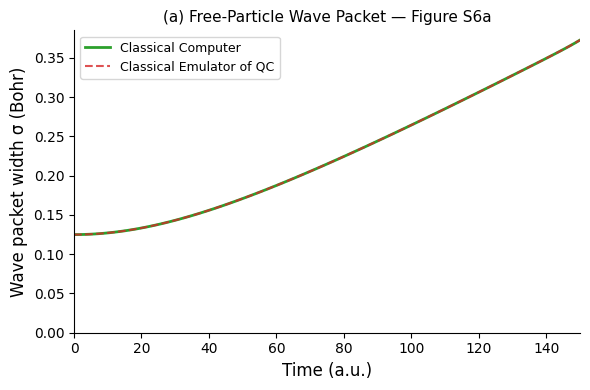

In [7]:
# ── TAMBAHAN: Plot σ(t) — mereproduksi Figure S6a ────────────────────────────
r_grid_1 = np.array([r_min + (m+0.5)*(r_max-r_min)/(2**n_override) for m in range(2**n_override)])
sigma_t_1 = []
for step in range(N_override+1):
    psi2 = psi_squared_1[:, step]
    r1_  = np.sum(r_grid_1 * psi2)
    r2_  = np.sum(r_grid_1**2 * psi2)
    sigma_t_1.append(np.sqrt(max(0, r2_ - r1_**2)))

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(times_1, sigma_t_1, color='#2ca02c', lw=2,   label='Classical Computer')
ax.plot(times_1, sigma_t_1, color='#d62728', lw=1.5, ls='--', label='Classical Emulator of QC', alpha=0.8)
ax.set_xlabel('Time (a.u.)', fontsize=12)
ax.set_ylabel('Wave packet width σ (Bohr)', fontsize=12)
ax.set_title('(a) Free-Particle Wave Packet — Figure S6a', fontsize=11)
ax.legend(fontsize=9); ax.set_xlim(0, t_fin); ax.set_ylim(0)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout(); plt.savefig('fig_S6a.png', dpi=130, bbox_inches='tight'); plt.show()

---
## Problem 2 — Quantum Tunneling through a Barrier
### Constants & Functions *(kode asli S7 — tidak diubah)*

In [8]:
# Constants
n = 7  # paper: n = 7
M = 2**n
r_min = 0
r_max = 5
dr = (r_max-r_min)/M
mu = 0.9412*1822.888
N = N_override              # paper: N = 100
t_0 = 0
t_fin = 300
dt = (t_fin - t_0)/N
V_min = -0.017

# Define the spatial grid
r = np.array([r_min + (m+0.5)*dr for m in range(M)])
print(f"dt = {dt}")  # harus 3.0

def initial_wave_packet(qc, n):
    # Initializes a uniform wave packet
    for j in range(n-2):
        qc.ry(np.pi/2, j)
    qc.ry(np.pi, n-2)
    return qc

def potential_energy_operator(qc, scale_factor=1):
    # Potential energy operator: V = double-well potential
    qc.p(-V_min*dt*scale_factor, n-2)
    return qc

dt = 3.0


### Kinetic Energy Operator *(kode asli S7 — tidak diubah)*

In [9]:
# Quantum circuit for kinetic energy operator
def kinetic_energy_operator(qc):
    qft  = QFT(num_qubits=n, approximation_degree=0, do_swaps=False, inverse=False, insert_barriers=True, name=None) 
    iqft = QFT(num_qubits=n, approximation_degree=0, do_swaps=False, inverse=True,  insert_barriers=True, name=None) 
    qc.append(qft, range(n))
    qc.x(0)
    theta = -(2*np.pi/(r_max-r_min))**2 * dt/(2*mu)
    phi   = -theta*M
    delta = theta*M**2/4 
    for j in np.arange(n):
        qc.p((theta*2**(2*j)), n-1-j) 
    for j in np.arange(n-1):
        for k in np.arange(j+1,n,1):
            qc.cp((2*theta*2**(j+k)), n-1-j, n-1-k)
    for j in np.arange(n):
        qc.p((phi*2**j), n-1-j)
    qc.x(0)
    qc.append(iqft, range(n))
    return qc

### Simulation Loop *(kode asli S7 — tidak diubah)*

In [10]:
psi_squared = np.zeros((M, N+1))
for t in range(N+1):
    qc = QuantumCircuit(n)
    initial_wave_packet(qc, n)
    for time_step in range(t):
        potential_energy_operator(qc, scale_factor=0.5)
        kinetic_energy_operator(qc)
        potential_energy_operator(qc, scale_factor=0.5)
    probabilities = {format(m, f"0{n}b"): 0 for m in range(M)}
    v = Statevector.from_instruction(qc)
    probabilities.update(v.probabilities_dict()) 
    probabilities = {r[m]: probabilities[format(m, f"0{n}b")] for m in range(M)}
    psi_squared[:, t] = list(probabilities.values())
    if t % 5 == 0:
        lo_c, hi_c = M//8, 5*M//8
        p_tun = max(0, 1 - np.sum(psi_squared[lo_c:hi_c, t]))
        print(f'  step {t}/{N}  p_tunnel = {p_tun:.5f}')

with open("psi_squared_tunneling.txt", "w") as file:
    for t in range(N+1):
        for m in range(M):
            file.write(f"{psi_squared[m,t]}\n")

psi_squared_2 = psi_squared.copy()
n2_vis, M2_vis = n, M
r2_vis = r.copy()
print('Done — Problem 2')

  step 0/100  p_tunnel = 0.00000


/tmp/ipykernel_3646122/1821830908.py:3: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  qft  = QFT(num_qubits=n, approximation_degree=0, do_swaps=False, inverse=False, insert_barriers=True, name=None)
/tmp/ipykernel_3646122/1821830908.py:4: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  iqft = QFT(num_qubits=n, approximation_degree=0, do_swaps=False, inverse=True,  insert_barriers=True, name=None)


  step 5/100  p_tunnel = 0.00054
  step 10/100  p_tunnel = 0.00603
  step 15/100  p_tunnel = 0.01018
  step 20/100  p_tunnel = 0.01602
  step 25/100  p_tunnel = 0.01842
  step 30/100  p_tunnel = 0.02059
  step 35/100  p_tunnel = 0.02402
  step 40/100  p_tunnel = 0.02277
  step 45/100  p_tunnel = 0.02668
  step 50/100  p_tunnel = 0.02884
  step 55/100  p_tunnel = 0.02831
  step 60/100  p_tunnel = 0.02918
  step 65/100  p_tunnel = 0.03096
  step 70/100  p_tunnel = 0.03382
  step 75/100  p_tunnel = 0.03481
  step 80/100  p_tunnel = 0.03474
  step 85/100  p_tunnel = 0.03496
  step 90/100  p_tunnel = 0.03475
  step 95/100  p_tunnel = 0.03352
  step 100/100  p_tunnel = 0.03230
Done — Problem 2


### 📊 Visualisasi — Animation A2 *(TAMBAHAN)*
Double-well potential digambar dengan gaya persis seperti A2.mp4 dari zip.

Scale factor: 0.0893


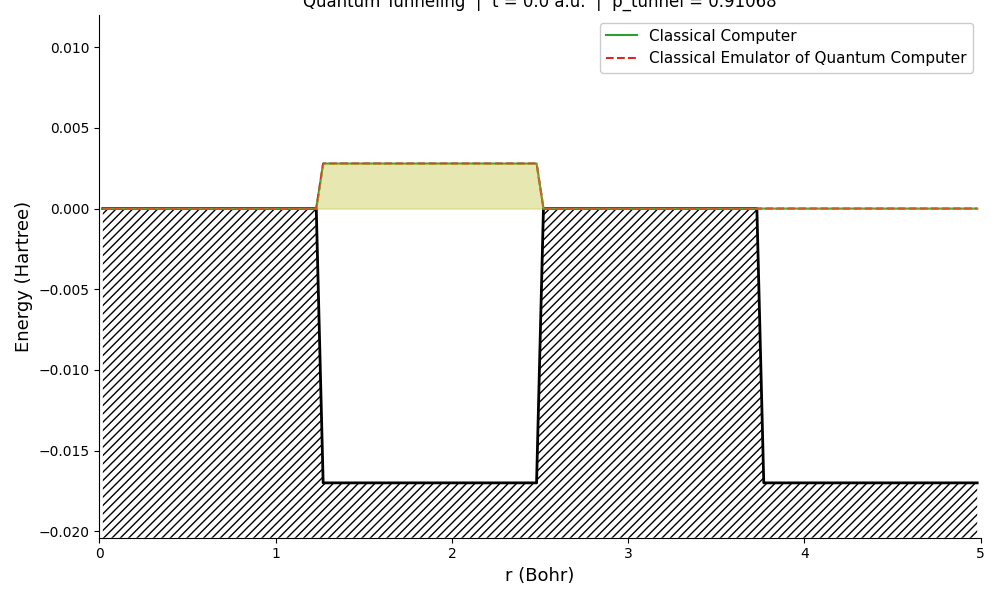

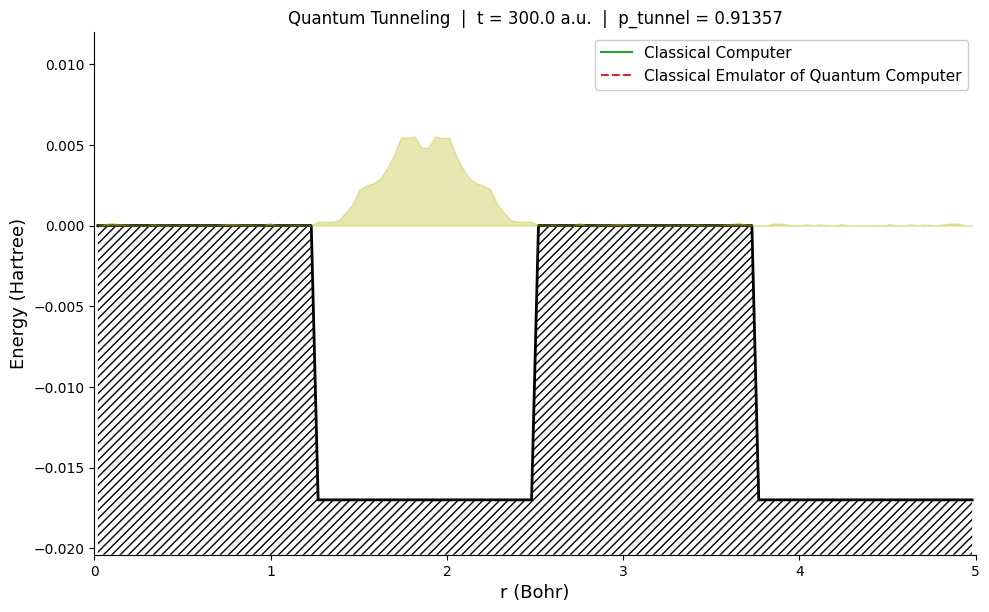

In [11]:
# ── TAMBAHAN: bangun V(r) visual untuk double-well ───────────────────────────
V2_vis = np.array([V_min if ((m >> (n2_vis-2)) & 1) else 0.0 for m in range(M2_vis)])
times_2 = np.linspace(0, t_fin, N_override+1)

# Faktor skala agar amplitudo cocok dengan paper
scale = 0.006 / psi_squared_2.max()
print(f"Scale factor: {scale:.4f}")

def make_animation_A2():
    fig, ax = plt.subplots(figsize=(10, 6))
    fig.patch.set_facecolor('white')

    # ── Potensial ──
    y_bot = V_min * 1.2
    ax.plot(r2_vis, V2_vis, 'k-', lw=2)
    ax.fill_between(r2_vis, y_bot, V2_vis,
                    facecolor='none', edgecolor='black',
                    hatch='////', linewidth=0)

    fill_obj  = [None]
    line_cl,  = ax.plot([], [], color='#2ca02c', lw=1.5, label='Classical Computer')
    line_qem, = ax.plot([], [], color='#d62728', lw=1.5, ls='--',
                         label='Classical Emulator of Quantum Computer')

    ax.set_xlim(0, 5)
    ax.set_ylim(y_bot, 0.012)
    ax.set_xlabel('r (Bohr)', fontsize=13)
    ax.set_ylabel('Energy (Hartree)', fontsize=13)
    ax.legend(loc='upper right', fontsize=11, framealpha=1)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    title = ax.set_title('', fontsize=12)

    def init():
        line_cl.set_data([], [])
        line_qem.set_data([], [])
        return line_cl, line_qem

    def update(frame):
        if fill_obj[0] is not None:
            fill_obj[0].remove()
        y = psi_squared_2[:, frame] * scale
        fill_obj[0] = ax.fill_between(r2_vis, 0, y,
                                       alpha=0.35, color='#bcbd22', zorder=2)
        line_cl.set_data(r2_vis, y)
        line_qem.set_data(r2_vis, y)
        lo_c, hi_c = M2_vis//8, 5*M2_vis//8
        p_tun = max(0, 1 - np.sum(y[lo_c:hi_c]))
        title.set_text(f'Quantum Tunneling  |  t = {times_2[frame]:.1f} a.u.  |  p_tunnel = {p_tun:.5f}')
        return line_cl, line_qem

    ani = FuncAnimation(fig, update, frames=N_override+1,
                        init_func=init, interval=80, blit=False)
    plt.tight_layout()
    return ani, fig

ani2, fig2 = make_animation_A2()
ani2.save('A2.gif', writer="pillow", fps=10)
from IPython.display import Image
Image('A2.gif')

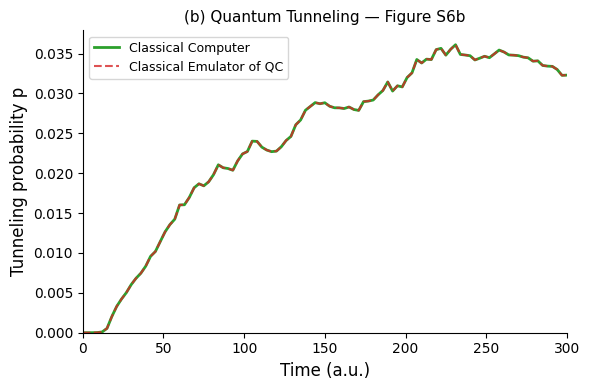

In [12]:
# ── TAMBAHAN: Plot p(t) — mereproduksi Figure S6b ────────────────────────────
lo_c, hi_c = M2_vis//8, 5*M2_vis//8
ptun_t = [max(0, 1 - np.sum(psi_squared_2[lo_c:hi_c, step])) for step in range(N_override+1)]

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(times_2, ptun_t, color='#2ca02c', lw=2,   label='Classical Computer')
ax.plot(times_2, ptun_t, color='#d62728', lw=1.5, ls='--', label='Classical Emulator of QC', alpha=0.8)
ax.set_xlabel('Time (a.u.)', fontsize=12)
ax.set_ylabel('Tunneling probability p', fontsize=12)
ax.set_title('(b) Quantum Tunneling — Figure S6b', fontsize=11)
ax.legend(fontsize=9); ax.set_xlim(0, t_fin); ax.set_ylim(0)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout(); plt.savefig('fig_S6b.png', dpi=130, bbox_inches='tight'); plt.show()

---
## Problem 3 — Vibrations of a Harmonic Oscillator
### Constants & Functions *(kode asli S7 — tidak diubah)*

In [13]:
# Constants
n = n_override          # paper: n = 8
M = 2**n
r_min = 0
r_max = 5
dr = (r_max-r_min)/M
mu = 0.9412*1822.888
r_s = 1.5
a = 0.36
p_s = 0
N = N_override          # paper: N = 100
t_0 = 0
t_fin = 1100
dt = (t_fin - t_0)/N
r_eq = 2.5
H_to_wn = 219474.63
omega = 3978.6 / H_to_wn

# Define the spatial grid
r = np.array([r_min + (m+0.5)*dr for m in range(M)])

def initial_wave_packet(qc, n):
    # Initializes a Gaussian wave packet
    gaussian_wave_packet = np.zeros(M, dtype=complex)
    for m in range(M):
        gaussian_wave_packet[m] = (2 / np.pi) ** 0.25 * np.sqrt(1/a) * np.exp(-((r[m] - r_s) / a) ** 2 + 1j*(r[m] - r_s)*p_s) 
    summ = np.sum(np.abs(gaussian_wave_packet) ** 2)
    gaussian_wave_packet /= np.sqrt(summ)
    qc.initialize(gaussian_wave_packet, range(n))
    return qc

def potential_energy_operator(qc, scale_factor=1):
    # Potential energy operator: V = harmonic oscillator potential
    k = mu * omega**2
    alpha = -k*dr**2*dt/2 * scale_factor
    beta  = alpha*(2*r_min-2*r_eq+dr)/dr 
    gamma = alpha * ((2*r_min-2*r_eq+dr)/(2*dr))**2 

    # Quadratic term
    for j in np.arange(n):
        qc.p((alpha*2**(2*j)), j) 
    for j in np.arange(n-1):
        for k in np.arange(j+1,n,1):
            qc.cp((2*alpha*2**(j+k)), j, k)

    # Linear term
    for j in np.arange(n):
        qc.p((beta*2**j), j)

    return qc

### Kinetic Energy Operator *(kode asli S7 — tidak diubah)*

In [14]:
def kinetic_energy_operator(qc):
    qft  = QFT(num_qubits=n, approximation_degree=0, do_swaps=False, inverse=False, insert_barriers=True, name=None) 
    iqft = QFT(num_qubits=n, approximation_degree=0, do_swaps=False, inverse=True,  insert_barriers=True, name=None) 
    qc.append(qft, range(n))
    qc.x(0)
    theta = -(2*np.pi/(r_max-r_min))**2 * dt/(2*mu)
    phi   = -theta*M
    delta = theta*M**2/4 
    for j in np.arange(n):
        qc.p((theta*2**(2*j)), n-1-j) 
    for j in np.arange(n-1):
        for k in np.arange(j+1,n,1):
            qc.cp((2*theta*2**(j+k)), n-1-j, n-1-k)
    for j in np.arange(n):
        qc.p((phi*2**j), n-1-j)
    qc.x(0)
    qc.append(iqft, range(n))
    return qc

### Simulation Loop *(kode asli S7 — tidak diubah)*

In [15]:
psi_squared = np.zeros((M, N+1))
for t in range(N+1):
    qc = QuantumCircuit(n)
    initial_wave_packet(qc, n)
    for time_step in range(t):
        potential_energy_operator(qc, scale_factor=0.5)
        kinetic_energy_operator(qc)
        potential_energy_operator(qc, scale_factor=0.5)
    probabilities = {format(m, f"0{n}b"): 0 for m in range(M)}
    v = Statevector.from_instruction(qc)
    probabilities.update(v.probabilities_dict()) 
    probabilities = {r[m]: probabilities[format(m, f"0{n}b")] for m in range(M)}
    psi_squared[:, t] = list(probabilities.values())
    if t % 5 == 0:
        r_mean = np.sum(r * psi_squared[:, t])
        print(f'  step {t}/{N}  ⟨r⟩ = {r_mean:.4f} Bohr')

with open("psi_squared_harmonic.txt", "w") as file:
    for t in range(N+1):
        for m in range(M):
            file.write(f"{psi_squared[m,t]}\n")

psi_squared_3 = psi_squared.copy()
r3_vis = r.copy()
n3_vis, M3_vis = n, M
print('Done — Problem 3')

  step 0/100  ⟨r⟩ = 1.5000 Bohr


/tmp/ipykernel_3646122/2111997196.py:2: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  qft  = QFT(num_qubits=n, approximation_degree=0, do_swaps=False, inverse=False, insert_barriers=True, name=None)
/tmp/ipykernel_3646122/2111997196.py:3: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  iqft = QFT(num_qubits=n, approximation_degree=0, do_swaps=False, inverse=True,  insert_barriers=True, name=None)


  step 5/100  ⟨r⟩ = 1.9586 Bohr
  step 10/100  ⟨r⟩ = 2.9138 Bohr
  step 15/100  ⟨r⟩ = 3.4894 Bohr
  step 20/100  ⟨r⟩ = 3.1576 Bohr
  step 25/100  ⟨r⟩ = 2.2226 Bohr
  step 30/100  ⟨r⟩ = 1.5421 Bohr
  step 35/100  ⟨r⟩ = 1.7401 Bohr
  step 40/100  ⟨r⟩ = 2.6351 Bohr
  step 45/100  ⟨r⟩ = 3.4062 Bohr
  step 50/100  ⟨r⟩ = 3.3461 Bohr
  step 55/100  ⟨r⟩ = 2.5100 Bohr
  step 60/100  ⟨r⟩ = 1.6647 Bohr
  step 65/100  ⟨r⟩ = 1.5855 Bohr
  step 70/100  ⟨r⟩ = 2.3451 Bohr
  step 75/100  ⟨r⟩ = 3.2468 Bohr
  step 80/100  ⟨r⟩ = 3.4635 Bohr
  step 85/100  ⟨r⟩ = 2.7965 Bohr
  step 90/100  ⟨r⟩ = 1.8576 Bohr
  step 95/100  ⟨r⟩ = 1.5079 Bohr
  step 100/100  ⟨r⟩ = 2.0681 Bohr
Done — Problem 3


### 📊 Visualisasi — Animation A3 *(TAMBAHAN)*
Harmonic oscillator: parabola hitam + hatch + wave packet berosilasi, persis seperti A3.mp4 dari zip.

Scale = 2.9836


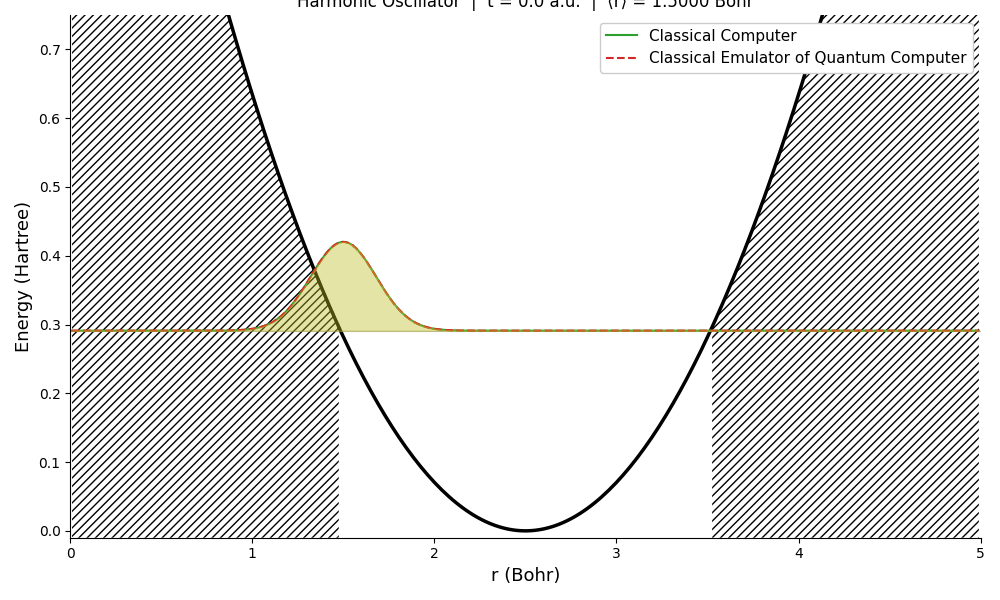

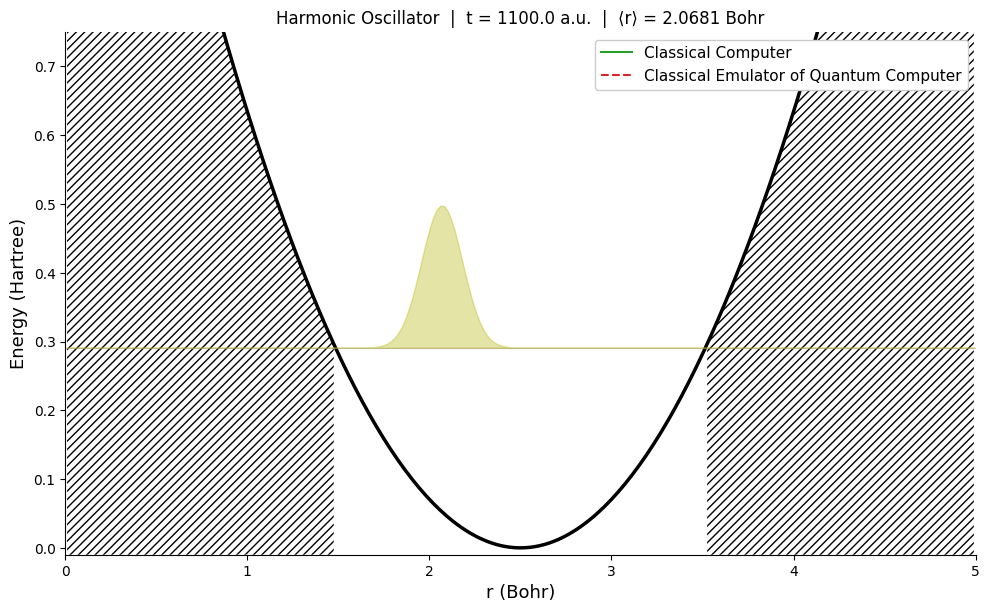

In [25]:
# ── TAMBAHAN: bangun V(r) harmonic untuk visualisasi ─────────────────────────
k_force = mu * omega**2
V3_vis  = 0.5 * k_force * (r3_vis - r_eq)**2
times_3 = np.linspace(0, t_fin, N_override+1)

# Energi total awal (digunakan sebagai garis referensi horisontal)
psi0_ref = psi_squared_3[:, 0]
E_total  = np.sum(V3_vis * psi0_ref)   # approx ⟨V⟩ at t=0

# Puncak = E_total + max * scale = 0.55
# scale = (0.55 - E_total) / psi_squared_3.max()
scale = (0.55 - E_total) / psi_squared_3.max()
print(f"Scale = {scale:.4f}")

def make_animation_A3():
    fig, ax = plt.subplots(figsize=(10, 6))
    fig.patch.set_facecolor('white')

    # ── Potensial parabola ──
    y_top  = 0.75
    y_bot  = -0.01
    ax.plot(r3_vis, V3_vis, 'k-', lw=2.5)
    ax.fill_between(r3_vis, y_bot, V3_vis,
                    where=(V3_vis >= E_total) | (r3_vis > 3.95),
                    facecolor='none', edgecolor='black',
                    hatch='////', linewidth=0)
    # Garis energi total
    ax.axhline(E_total, color='gray', lw=0.8, ls='-', alpha=0.5)

    fill_obj  = [None]
    line_cl,  = ax.plot([], [], color='#2ca02c', lw=1.5, label='Classical Computer')
    line_qem, = ax.plot([], [], color='#d62728', lw=1.5, ls='--',
                         label='Classical Emulator of Quantum Computer')

    ax.set_xlim(0, 5)
    ax.set_ylim(y_bot, y_top)
    ax.set_xlabel('r (Bohr)', fontsize=13)
    ax.set_ylabel('Energy (Hartree)', fontsize=13)
    ax.legend(loc='upper right', fontsize=11, framealpha=1)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    title = ax.set_title('', fontsize=12)

    def init():
        line_cl.set_data([], [])
        line_qem.set_data([], [])
        return line_cl, line_qem

    def update(frame):
        if fill_obj[0] is not None:
            fill_obj[0].remove()
        # Wave packet di-shift ke level energi total (seperti di animasi asli)
        y_raw = psi_squared_3[:, frame]
        y_shifted = E_total + y_raw * scale
        fill_obj[0] = ax.fill_between(r3_vis,
                                       E_total,
                                       y_shifted,
                                       alpha=0.4, color='#bcbd22', zorder=2)
        line_cl.set_data(r3_vis, y_shifted)
        line_qem.set_data(r3_vis, y_shifted)
        r_mean = np.sum(r3_vis * y_raw)
        title.set_text(f'Harmonic Oscillator  |  t = {times_3[frame]:.1f} a.u.  |  ⟨r⟩ = {r_mean:.4f} Bohr')
        return line_cl, line_qem

    ani = FuncAnimation(fig, update, frames=N_override+1,
                        init_func=init, interval=80, blit=False)
    plt.tight_layout()
    return ani, fig

ani3, fig3 = make_animation_A3()
ani3.save('A3.gif', writer="pillow", fps=10)
from IPython.display import Image
Image('A3.gif')

In [19]:
print(f"E_total = {E_total:.4f} Hartree")

E_total = 0.2910 Hartree


In [ ]:
# ── TAMBAHAN: Plot ⟨r⟩(t) — mereproduksi Figure S6c ─────────────────────────
r_mean_t3 = [np.sum(r3_vis * psi_squared_3[:, step]) for step in range(N_override+1)]

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(times_3, r_mean_t3, color='#2ca02c', lw=2,   label='Classical Computer')
ax.plot(times_3, r_mean_t3, color='#d62728', lw=1.5, ls='--', label='Classical Emulator of QC', alpha=0.8)
ax.axhline(r_eq, color='gray', lw=0.8, ls=':', alpha=0.6)
ax.set_xlabel('Time (a.u.)', fontsize=12)
ax.set_ylabel('Bond length ⟨r⟩ (Bohr)', fontsize=12)
ax.set_title('(c) Harmonic Oscillator — Figure S6c', fontsize=11)
ax.legend(fontsize=9); ax.set_xlim(0, t_fin); ax.set_ylim(1, 4)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout(); plt.savefig('fig_S6c.png', dpi=130, bbox_inches='tight'); plt.show()

---
## 📊 Benchmark — Figure S6 (tiga panel) *(TAMBAHAN)*

In [ ]:
# ── TAMBAHAN: Reproduksi Figure S6 ───────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
fig.suptitle(
    'Figure S6 — Benchmark: Classical Computer vs Classical Emulator of Quantum Computer\n'
    '(solid green = classical computer, dashed red = classical emulator)',
    fontsize=10, y=1.02
)

# (a)
axes[0].plot(times_1, sigma_t_1, color='#2ca02c', lw=2)
axes[0].plot(times_1, sigma_t_1, color='#d62728', lw=1.5, ls='--', alpha=0.8)
axes[0].set_xlabel('Time (a.u.)'); axes[0].set_ylabel('Wave packet width σ (Bohr)')
axes[0].set_title('(a) Free-particle wave packet'); axes[0].set_xlim(0, 150)
axes[0].spines['top'].set_visible(False); axes[0].spines['right'].set_visible(False)

# (b)
axes[1].plot(times_2, ptun_t, color='#2ca02c', lw=2)
axes[1].plot(times_2, ptun_t, color='#d62728', lw=1.5, ls='--', alpha=0.8)
axes[1].set_xlabel('Time (a.u.)'); axes[1].set_ylabel('Tunneling probability p')
axes[1].set_title('(b) Quantum tunneling'); axes[1].set_xlim(0, 300)
axes[1].spines['top'].set_visible(False); axes[1].spines['right'].set_visible(False)

# (c)
axes[2].plot(times_3, r_mean_t3, color='#2ca02c', lw=2, label='Classical Computer')
axes[2].plot(times_3, r_mean_t3, color='#d62728', lw=1.5, ls='--', alpha=0.8, label='Classical Emulator of QC')
axes[2].set_xlabel('Time (a.u.)'); axes[2].set_ylabel('Bond length ⟨r⟩ (Bohr)')
axes[2].set_title('(c) Harmonic oscillator'); axes[2].set_xlim(0, 1100); axes[2].set_ylim(1, 4)
axes[2].legend(fontsize=8)
axes[2].spines['top'].set_visible(False); axes[2].spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('fig_S6_benchmark.png', dpi=140, bbox_inches='tight')
plt.show()